In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

iris = load_iris()

# Use petal length and petal width
X = iris.data[:, [2, 3]]
y = iris.target

# Use only Setosa and Versicolor for easy 2-class visualization
mask = y < 2
X, y = X[mask], y[mask]

In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

svm = SVC(kernel="linear", C=1)
svm.fit(X, y)

print("Accuracy:", svm.score(X, y))

Accuracy: 1.0


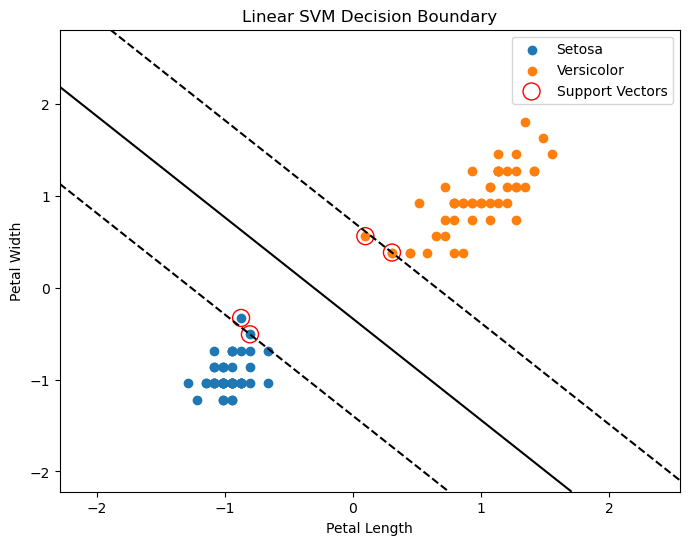

In [9]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.scatter(X[y==0,0], X[y==0,1], label="Setosa")
plt.scatter(X[y==1,0], X[y==1,1], label="Versicolor")

# Decision boundary and margins
plt.contour(xx, yy, Z, levels=[-1, 0, 1],
            colors="black", linestyles=["--", "-", "--"])

# Support vectors
plt.scatter(svm.support_vectors_[:,0],
            svm.support_vectors_[:,1],
            s=150, facecolors="none",
            edgecolors="red",
            label="Support Vectors")

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

In [10]:
w = svm.coef_[0]

margin = 2 / np.linalg.norm(w)

print("Margin width:", margin)
print("Support vectors:", len(svm.support_vectors_))

Margin width: 1.4190273905048953
Support vectors: 4
